In [1]:
import os 
import numpy as np
import pandas as pd
import anndata
import scanpy as sc
import matplotlib.pyplot as plt
import scgen
import seaborn as sns
from scipy import stats
import matplotlib
import scipy.sparse as sparse
from scgen.file_utils import ensure_dir, ensure_dir_for_file, get_dense_X
matplotlib.rc('ytick', labelsize=14)
matplotlib.rc('xtick', labelsize=14)
sc.set_figure_params(dpi_save=300)

/home/sagemaker-user/.conda/envs/scgen-repro-env/lib/python3.10/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound
2026-02-20 03:13:49.414932: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-02-20 03:13:49.512824: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH:

Instructions for updating:
non-resource variables are not supported in the long term


In [2]:
path_to_save = "../results/Figures/Supplemental Figure 5/"
ensure_dir(path_to_save)
sc.settings.figdir = path_to_save

In [3]:
pbmc = scgen.load_file("../data/train_pbmc.h5ad")
pbmc

/home/sagemaker-user/.conda/envs/scgen-repro-env/lib/python3.10/site-packages/anndata/compat/__init__.py:371: FutureWarning: Moving element from .uns['neighbors']['distances'] to .obsp['distances'].

This is where adjacency matrices should go now.
  warn(
/home/sagemaker-user/.conda/envs/scgen-repro-env/lib/python3.10/site-packages/anndata/compat/__init__.py:371: FutureWarning: Moving element from .uns['neighbors']['connectivities'] to .obsp['connectivities'].

This is where adjacency matrices should go now.
  warn(


AnnData object with n_obs × n_vars = 16893 × 6998
    obs: 'condition', 'n_counts', 'n_genes', 'mt_frac', 'cell_type'
    var: 'gene_symbol', 'n_cells'
    uns: 'cell_type_colors', 'condition_colors', 'neighbors'
    obsm: 'X_pca', 'X_tsne', 'X_umap'
    obsp: 'distances', 'connectivities'

In [4]:
pbmc.obs.groupby(['cell_type', 'condition']).size()

/tmp/ipykernel_26699/191267336.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pbmc.obs.groupby(['cell_type', 'condition']).size()


cell_type    condition 
CD4T         control       2437
             stimulated    3127
CD14+Mono    control       1946
             stimulated     615
B            control        818
             stimulated     993
CD8T         control        574
             stimulated     541
NK           control        517
             stimulated     646
FCGR3A+Mono  control       1100
             stimulated    2501
Dendritic    control        615
             stimulated     463
dtype: int64

In [5]:
network = scgen.VAEArith(x_dimension=pbmc.shape[1], z_dimension=100, model_path="../models/scGen/pbmc/CD4T/scgen")
network.restore_model()

2026-02-20 03:13:51.562536: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-02-20 03:13:51.648895: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: /usr/local/nvidia/lib:/usr/local/nvidia/lib64
2026-02-20 03:13:51.649005: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcublas.so.11'; dlerror: libcublas.so.11: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: /usr/local/nvidia/lib:/usr/local/nvidia/lib64
2026-02-20 03:13:51.649097: W tensorflow/stream_executor/platform/default/

INFO:tensorflow:Restoring parameters from ../models/scGen/pbmc/CD4T/scgen


In [6]:
scgen_reconstructed_pbmc = scgen.load_file("../data/reconstructed/scGen/pbmc.h5ad")
scgen_reconstructed_pbmc

AnnData object with n_obs × n_vars = 24900 × 6998
    obs: 'condition', 'cell_type', 'batch'

In [7]:
scgen_reconstructed_pbmc.obs.groupby(['condition']).size()

/tmp/ipykernel_26699/635862554.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  scgen_reconstructed_pbmc.obs.groupby(['condition']).size()


condition
B_ctrl                    818
B_pred_stim               818
B_real_stim               993
CD4T_ctrl                2437
CD4T_pred_stim           2437
CD4T_real_stim           3127
CD8T_ctrl                 574
CD8T_pred_stim            574
CD8T_real_stim            541
CD14+Mono_ctrl           1946
CD14+Mono_pred_stim      1946
CD14+Mono_real_stim       615
Dendritic_ctrl            615
Dendritic_pred_stim       615
Dendritic_real_stim       463
FCGR3A+Mono_ctrl         1100
FCGR3A+Mono_pred_stim    1100
FCGR3A+Mono_real_stim    2501
NK_ctrl                   517
NK_pred_stim              517
NK_real_stim              646
dtype: int64

In [8]:
pca_reconstructed_pbmc = scgen.load_file("../data/reconstructed/PCAVecArithm/PCA_pbmc.h5ad")
pca_reconstructed_pbmc

AnnData object with n_obs × n_vars = 24900 × 6998
    obs: 'condition', 'cell_type', 'batch'

In [9]:
pca_reconstructed_pbmc.obs.groupby(['condition']).size()

/tmp/ipykernel_26699/3341411402.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pca_reconstructed_pbmc.obs.groupby(['condition']).size()


condition
B_ctrl                    818
B_pred_stim               818
B_real_stim               993
CD4T_ctrl                2437
CD4T_pred_stim           2437
CD4T_real_stim           3127
CD8T_ctrl                 574
CD8T_pred_stim            574
CD8T_real_stim            541
CD14+Mono_ctrl           1946
CD14+Mono_pred_stim      1946
CD14+Mono_real_stim       615
Dendritic_ctrl            615
Dendritic_pred_stim       615
Dendritic_real_stim       463
FCGR3A+Mono_ctrl         1100
FCGR3A+Mono_pred_stim    1100
FCGR3A+Mono_real_stim    2501
NK_ctrl                   517
NK_pred_stim              517
NK_real_stim              646
dtype: int64

In [10]:
def score(adata, data_name, n_deg=10, n_genes=1000, condition_key="condition", cell_type_key="cell_type",
          conditions={"stim": "stimulated", "ctrl": "control"},
          sortby="median_score"):
    import scanpy as sc
    import numpy as np
    from scipy.stats import entropy
    import pandas as pd
    sc.tl.rank_genes_groups(adata, groupby=condition_key, method="wilcoxon", n_genes=n_genes)
    gene_names = adata.uns["rank_genes_groups"]['names'][conditions['stim']]
    gene_lfcs = adata.uns["rank_genes_groups"]['logfoldchanges'][conditions['stim']]
    diff_genes_df = pd.DataFrame({"names": gene_names, "lfc": gene_lfcs})
    diff_genes = diff_genes_df["names"].tolist()[:n_genes]
    print(len(diff_genes))

    adata_deg = adata[:, diff_genes].copy()
    cell_types = adata_deg.obs[cell_type_key].cat.categories.tolist()
    lfc_temp = np.zeros((len(cell_types), n_genes))
    for j, ct in enumerate(cell_types):
        if cell_type_key == "cell_type":  # if data is pbmc
            stim = adata_deg[(adata_deg.obs[cell_type_key] == ct) &
                             (adata_deg.obs[condition_key] == conditions["stim"])].X.mean(0).A1
            ctrl = adata_deg[(adata_deg.obs[cell_type_key] == ct) &
                             (adata_deg.obs[condition_key] == conditions["ctrl"])].X.mean(0).A1
        else:
            stim = adata_deg[(adata_deg.obs[cell_type_key] == ct) &
                             (adata_deg.obs[condition_key] == conditions["stim"])].X.mean(0)
            ctrl = adata_deg[(adata_deg.obs[cell_type_key] == ct) &
                             (adata_deg.obs[condition_key] == conditions["ctrl"])].X.mean(0)
        lfc_temp[j] = np.abs((stim - ctrl)[None, :])
    norm_lfc = lfc_temp / lfc_temp.sum(0).reshape((1, n_genes))
    ent_scores = entropy(norm_lfc)
    median = np.median(lfc_temp, axis=0)
    med_scores = np.max(np.abs((lfc_temp - median)), axis=0)
    df_score = pd.DataFrame({"genes": adata_deg.var_names.tolist(), "median_score": med_scores,
                             "entropy_score": ent_scores})
    if sortby == "median_score":
        return df_score.sort_values(by=['median_score'], ascending=False).iloc[:n_deg, :]
    else:
        return df_score.sort_values(by=['entropy_score'], ascending=False).iloc[:n_deg, :]

In [11]:
def sanitize_for_windows(dir_or_file):
    import re
    from pathlib import Path
    forbidden_chars = re.compile(r'[<>:"\\/?|*]')

    path = Path(dir_or_file)
    stem = forbidden_chars.sub('-', path.stem)
    suffix = path.suffix

    stem = stem.rstrip(" .")

    if path.parent:
        return f"{path.parent}/{stem}{suffix}"
    return f"{stem}{suffix}"

In [12]:
def plot_boxplot(recon_data, 
                 method, 
                 data_name="pbmc", 
                 n_genes=100, 
                 restore=True, 
                 score_type="median_score", 
                 y_measure="SE",
                 scale="log"):
    if data_name == "pbmc":
        stim_key = "stimulated"
        ctrl_key = "control"
        cell_type_key = "cell_type"
        train = scgen.load_file("../data/train_pbmc.h5ad")
    elif data_name == "hpoly":
        stim_key = "Hpoly.Day10"
        ctrl_key = "Control"
        cell_type_key = "cell_label"
        train = scgen.load_file("../data/train_hpoly.h5ad")
    elif data_name == "salmonella":
        stim_key = "Salmonella"
        ctrl_key = "Control"
        cell_type_key = "cell_label"
        train = scgen.load_file("../data/train_salmonella.h5ad")
    import matplotlib
    matplotlib.rc('ytick', labelsize=14)
    matplotlib.rc('xtick', labelsize=14)
    conditions = {"ctrl": ctrl_key, "stim": stim_key}

    sc.settings.figdir = path_to_save

    diff_genes = score(train, data_name, n_deg=10 * n_genes, n_genes=500, cell_type_key=cell_type_key, conditions=conditions,
                       sortby=score_type)
    diff_genes = diff_genes["genes"].tolist()
    
    # epsilon = 1e-7
    ensure_dir(sanitize_for_windows(os.path.join(path_to_save, f"./boxplots/Top_{10 * n_genes}/{y_measure}/")))
    if not restore:
        n_cell_types = len(train.obs[cell_type_key].unique().tolist())
        all_scores = np.zeros(shape=(n_cell_types * 10 * n_genes, 1))
        for bin_idx in range(10):
            for cell_type_idx, cell_type in enumerate(train.obs[cell_type_key].unique().tolist()):
                real_stim = recon_data[(recon_data.obs[cell_type_key] == cell_type) & (
                        recon_data.obs["condition"] == f"{cell_type}_real_stim")]
                pred_stim = recon_data[(recon_data.obs[cell_type_key] == cell_type) & (
                        recon_data.obs["condition"] == f"{cell_type}_pred_stim")]

                real_stim = real_stim[:, diff_genes[bin_idx * n_genes:(bin_idx + 1) * n_genes]]
                pred_stim = pred_stim[:, diff_genes[bin_idx * n_genes:(bin_idx + 1) * n_genes]]
                real_stim_X = get_dense_X(real_stim)
                pred_stim_X = get_dense_X(pred_stim)
                real_stim_avg = np.average(real_stim_X, axis=0)
                pred_stim_avg = np.average(pred_stim_X, axis=0)
                if y_measure == "SE":  # (x - xhat) ^ 2
                    y_measures = np.abs(np.square(real_stim_avg - pred_stim_avg))
                    y_measures_reshaped = np.reshape(y_measures, (-1,))
                elif y_measure == "AE":  # x - xhat
                    y_measures = np.abs(real_stim_avg - pred_stim_avg)
                    y_measures_reshaped = np.reshape(y_measures, (-1,))
                elif y_measure == "AE:x":  # (x - xhat) / x
                    y_measures = np.abs(real_stim_avg - pred_stim_avg)
                    y_measures = np.divide(y_measures, real_stim_avg)
                    y_measures_reshaped = np.reshape(y_measures, (-1,))
                elif y_measure == "SE:x^2":  # (x - xhat) / x^2
                    y_measures = np.abs(np.square(real_stim_avg - pred_stim_avg))
                    y_measures = np.divide(y_measures, np.power(real_stim_avg, 2))
                    y_measures_reshaped = np.reshape(y_measures, (-1,))
                elif y_measure == "AE:max(x, 1)":  # (x - xhat) / max(x, 1)
                    y_measures = np.abs(real_stim_avg - pred_stim_avg)
                    y_measures = np.divide(y_measures, np.maximum(real_stim_avg, 1.0))
                    y_measures_reshaped = np.reshape(y_measures, (-1,))
                elif y_measure == "SE:max(x, 1)^2":  # (x - xhat)^2 / max(x, 1)^2
                    y_measures = np.abs(np.square(real_stim_avg - pred_stim_avg))
                    y_measures = np.divide(y_measures, np.power(np.maximum(real_stim_avg, 1.0), 2))
                    y_measures_reshaped = np.reshape(y_measures, (-1,))
                elif y_measure == "SE:max(x, 1)":  # (x - xhat)^2 / max(x, 1)
                    y_measures = np.abs(np.square(real_stim_avg - pred_stim_avg))
                    y_measures = np.divide(y_measures, np.power(np.maximum(real_stim_avg, 1.0), 1.0))
                    y_measures_reshaped = np.reshape(y_measures, (-1,))
                elif y_measure == "1 - AE:x":  # 1 - ((x - xhat) / x)
                    y_measures = np.abs(real_stim_avg - pred_stim_avg)
                    y_measures = np.divide(y_measures, real_stim_avg)
                    y_measures = np.abs(1.0 - y_measures)
                    y_measures_reshaped = np.reshape(y_measures, (-1,))
                elif y_measure == "1 - SE:x^2":  # 1 - ((x - xhat) / x)^2
                    y_measures = np.abs(np.square(real_stim_avg - pred_stim_avg))
                    y_measures = np.divide(y_measures, np.power(real_stim_avg, 2))
                    y_measures = np.abs(1.0 - y_measures)
                    y_measures_reshaped = np.reshape(y_measures, (-1,))
                elif y_measure == "1 - AE:max(x, 1)":  # 1 - ((x - xhat) / max(x, 1.0))
                    y_measures = np.abs(real_stim_avg - pred_stim_avg)
                    y_measures = np.true_divide(y_measures, np.maximum(real_stim_avg, 1.0))
                    y_measures = np.abs(1.0 - y_measures)
                    y_measures_reshaped = np.reshape(y_measures, (-1,))
                elif y_measure == "1 - SE:max(x, 1)^2":  # 1 - ((x - xhat) / max(x, 1.0))
                    y_measures = np.abs(np.square(real_stim_avg - pred_stim_avg))
                    y_measures = np.true_divide(y_measures, np.power(np.maximum(real_stim_avg, 1.0), 2))
                    y_measures = np.abs(1.0 - y_measures)
                    y_measures_reshaped = np.reshape(y_measures, (-1,))
                if scale == "log":
                    y_measures_reshaped = np.log(y_measures_reshaped)                    
                start = n_cell_types * n_genes * bin_idx
                all_scores[start + n_genes * cell_type_idx:start + n_genes * (cell_type_idx + 1),
                0] = y_measures_reshaped
        all_scores = np.reshape(all_scores, (-1,))
        print(all_scores.shape)
    else:
        all_scores = np.loadtxt(
            fname=sanitize_for_windows(f"./boxplots/Top_{10 * n_genes}/{y_measure}/y_measures_{score_type}_{n_genes}_({y_measure}).txt"),
            delimiter=",")
    import seaborn as sns
    conditions = [f"Bin-{i // (n_cell_types * n_genes) + 1}" for i in range(n_cell_types * 10 * n_genes)]
    all_scores_df = pd.DataFrame({"scores": all_scores})
    all_scores_df["conditions"] = conditions
    ax = sns.boxplot(data=all_scores_df, x="conditions", y="scores", whis=np.inf)
    if scale != "log" and y_measure == "AE:max(x, 1)":
        ax.set_ylim(0.0, 1.75)
    elif scale != "log" and y_measure == "SE:max(x, 1)":
        ax.set_ylim(0.0, 3.0)
    elif y_measure == "AE:max(x, 1)":
        ax.set_ylim(-15.0, 0.5)
    elif y_measure == "SE:max(x, 1)":
        ax.set_ylim(-30.5, 1.0)
    xlabels = ['Bin-%i' % i for i in range(10)]
    ax.set_xticklabels(xlabels, rotation=90)
    if y_measure == "SE":
        plt.ylabel("(x - xhat) ^ 2")
    elif y_measure == "AE":
        plt.ylabel("|x - xhat|")
    elif y_measure == "AE:x":
        plt.ylabel("|x - xhat| / x")
    elif y_measure == "SE:x^2":
        plt.ylabel("((x - xhat) ^ 2) / (x ^ 2)")
    elif y_measure == "AE:max(x, 1)":
        if scale == "log":
            plt.ylabel("log(|x - xhat| / max(x, 1))")
        else: 
            plt.ylabel("|x - xhat| / max(x, 1)")
    elif y_measure == "SE:max(x, 1)^2":
        plt.ylabel("(x - xhat)^2 / max(x, 1)^2")
    elif y_measure == "SE:max(x, 1)":
        if scale == "log":
            plt.ylabel("log((x - xhat)^2 / max(x, 1))")
        else:
            plt.ylabel("(x - xhat)^2 / max(x, 1)")
    elif y_measure == "1 - AE:x":
        plt.ylabel("1 - (|x - xhat| / x)")
    elif y_measure == "1 - SE:x^2":
        plt.ylabel("1 - ((x - xhat)^2 / x^2)")
    elif y_measure == "1 - AE:max(x, 1)":
        plt.ylabel("1 - (|x - xhat| / max(x, 1))")
    elif y_measure == "1 - SE:max(x, 1)^2":
        plt.ylabel("1 - ((x - xhat)^2 / max(x, 1)^2)")
    plt.tight_layout()
    name = os.path.join(path_to_save, f"./boxplots/Top_{10 * n_genes}/{sanitize_for_windows(y_measure)}/{method}_{data_name}_boxplot_{score_type}_{n_genes}_{scale}.pdf")
    plt.savefig((name), dpi=300)
    plt.show()
    plt.close()

    all_scores = np.reshape(all_scores, (-1, 1))

In [13]:
def stacked_violin_plot(recon_data, method, figure, data_name="pbmc", score_type="median_score"):
    if data_name == "pbmc":
        stim_key = "stimulated"
        ctrl_key = "control"
        cell_type_key = "cell_type"
        train = scgen.load_file("../data/train_pbmc.h5ad")
    elif data_name == "hpoly":
        stim_key = "Hpoly.Day10"
        ctrl_key = "Control"
        cell_type_key = "cell_label"
        train = scgen.load_file("../data/train_hpoly.h5ad")
    elif data_name == "salmonella":
        stim_key = "Salmonella"
        ctrl_key = "Control"
        cell_type_key = "cell_label"
        train = scgen.load_file("../data/train_salmonella.h5ad")
    sc.settings.figdir = path_to_save
    conditions = {"ctrl": ctrl_key, "stim": stim_key}

    diff_genes = score(train, data_name, n_deg=10, n_genes=500, cell_type_key=cell_type_key, conditions=conditions,
                       sortby=score_type)
    diff_genes = diff_genes["genes"].tolist()
    sc.pl.stacked_violin(recon_data,
                         var_names=diff_genes,
                         groupby="condition",
                         save=f"_{method}_{score_type}_{data_name}.pdf",
                         swap_axes=True,
                         show=True)
    src_filename = os.path.join(path_to_save, f"stacked_violin__{method}_{score_type}_{data_name}.pdf")
    dst_filename = os.path.join(path_to_save, f"SupplFig5{figure}_{method}_{score_type}_{data_name}.pdf")
    os.rename(src=ensure_dir_for_file(src_filename), dst=ensure_dir_for_file(dst_filename))

/home/sagemaker-user/.conda/envs/scgen-repro-env/lib/python3.10/site-packages/anndata/compat/__init__.py:371: FutureWarning: Moving element from .uns['neighbors']['distances'] to .obsp['distances'].

This is where adjacency matrices should go now.
  warn(
/home/sagemaker-user/.conda/envs/scgen-repro-env/lib/python3.10/site-packages/anndata/compat/__init__.py:371: FutureWarning: Moving element from .uns['neighbors']['connectivities'] to .obsp['connectivities'].

This is where adjacency matrices should go now.
  warn(


500


findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

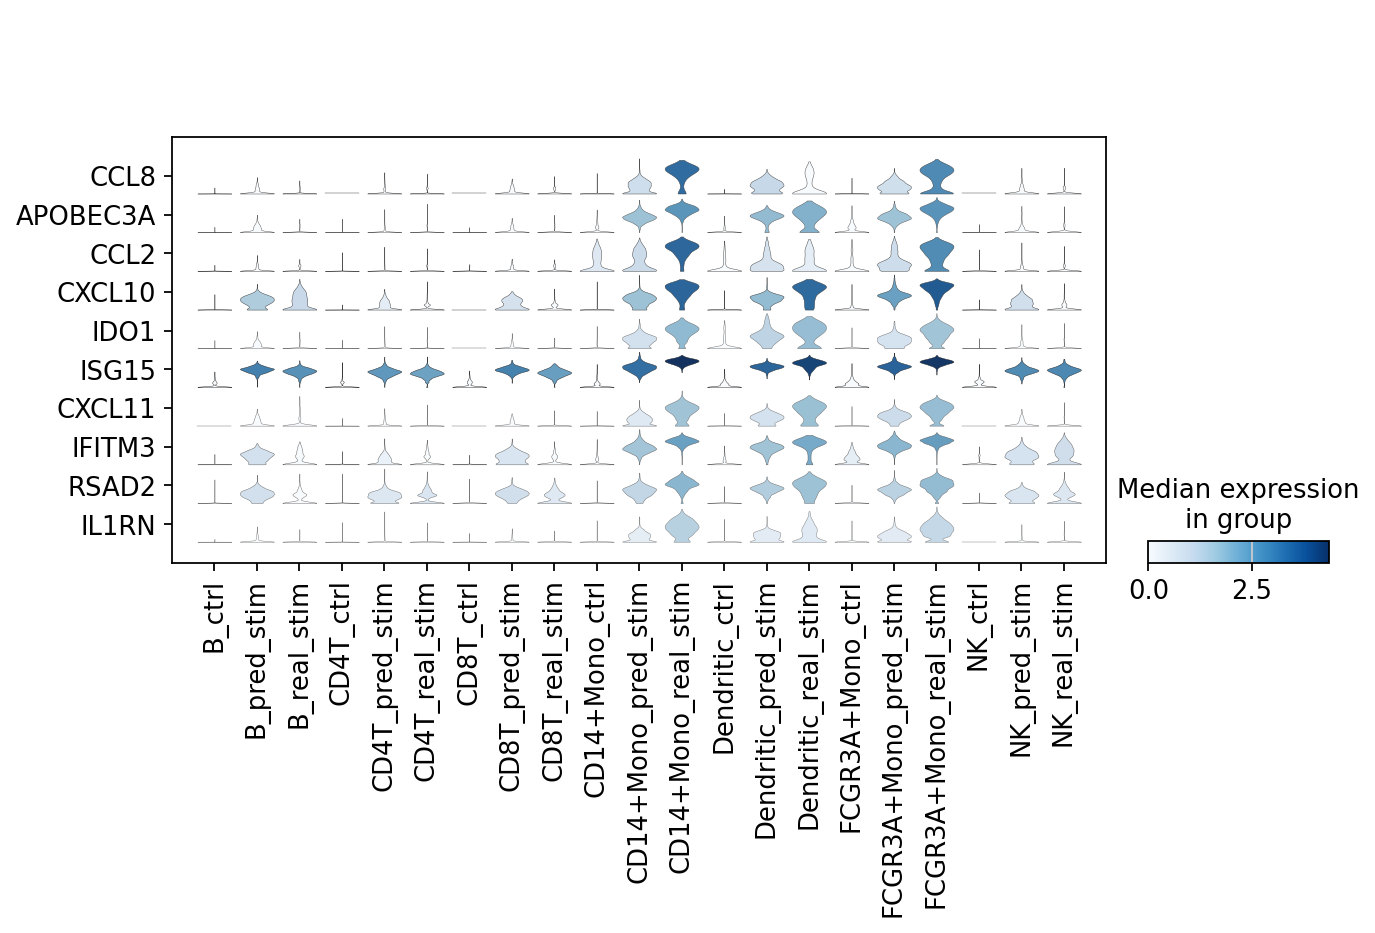

/home/sagemaker-user/.conda/envs/scgen-repro-env/lib/python3.10/site-packages/anndata/compat/__init__.py:371: FutureWarning: Moving element from .uns['neighbors']['distances'] to .obsp['distances'].

This is where adjacency matrices should go now.
  warn(
/home/sagemaker-user/.conda/envs/scgen-repro-env/lib/python3.10/site-packages/anndata/compat/__init__.py:371: FutureWarning: Moving element from .uns['neighbors']['connectivities'] to .obsp['connectivities'].

This is where adjacency matrices should go now.
  warn(


500


findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

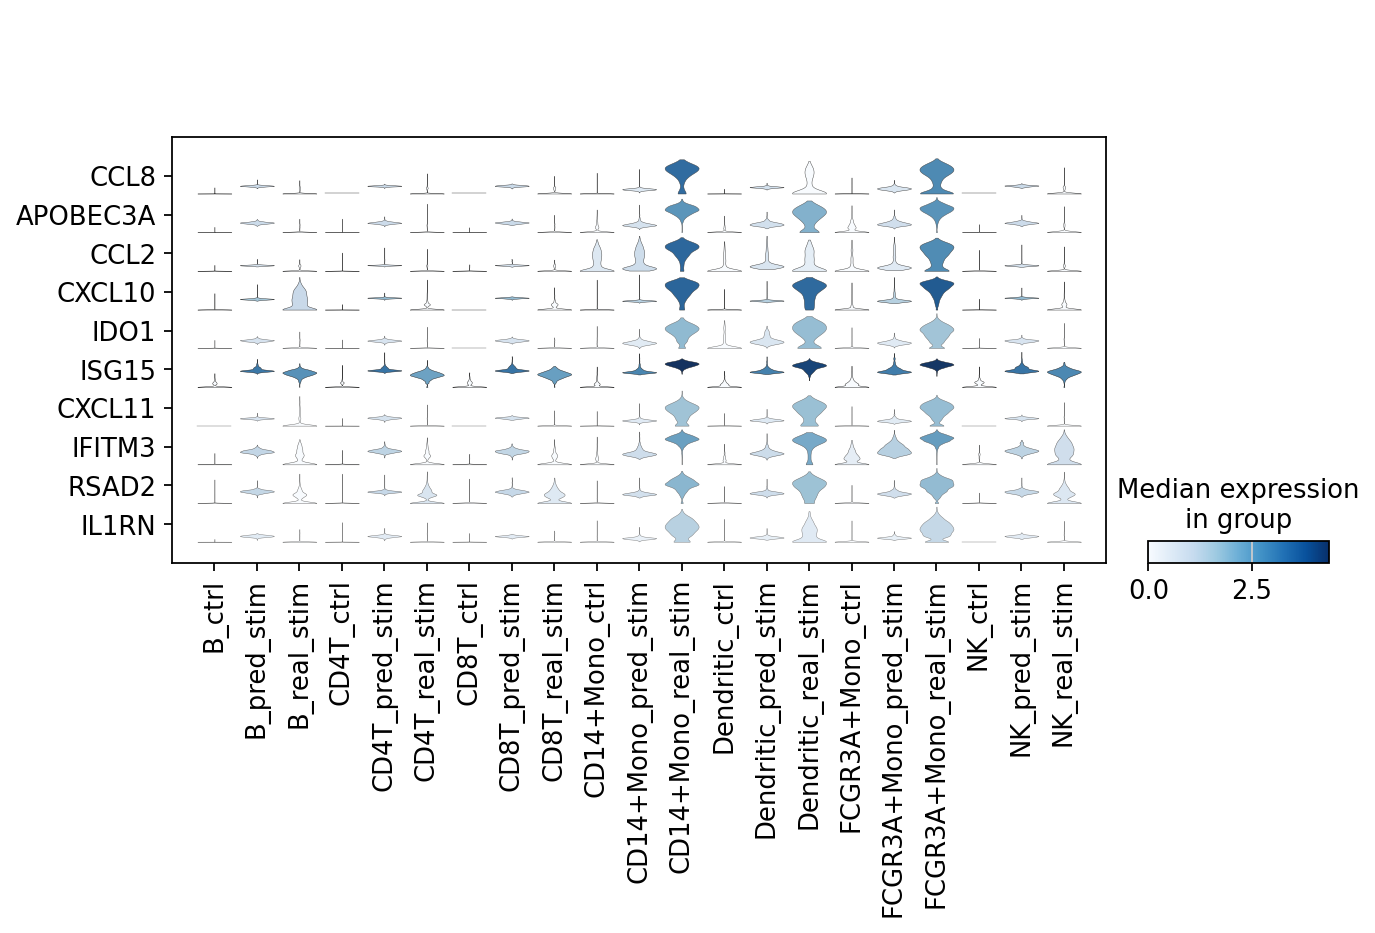

In [14]:
stacked_violin_plot(scgen_reconstructed_pbmc, "scGen", "a", "pbmc", "median_score")
stacked_violin_plot(pca_reconstructed_pbmc, "PCA", "c", "pbmc", "median_score")

/home/sagemaker-user/.conda/envs/scgen-repro-env/lib/python3.10/site-packages/anndata/compat/__init__.py:371: FutureWarning: Moving element from .uns['neighbors']['distances'] to .obsp['distances'].

This is where adjacency matrices should go now.
  warn(
/home/sagemaker-user/.conda/envs/scgen-repro-env/lib/python3.10/site-packages/anndata/compat/__init__.py:371: FutureWarning: Moving element from .uns['neighbors']['connectivities'] to .obsp['connectivities'].

This is where adjacency matrices should go now.
  warn(


500


/tmp/ipykernel_26699/962300281.py:124: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(xlabels, rotation=90)
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: F

(3500,)


findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

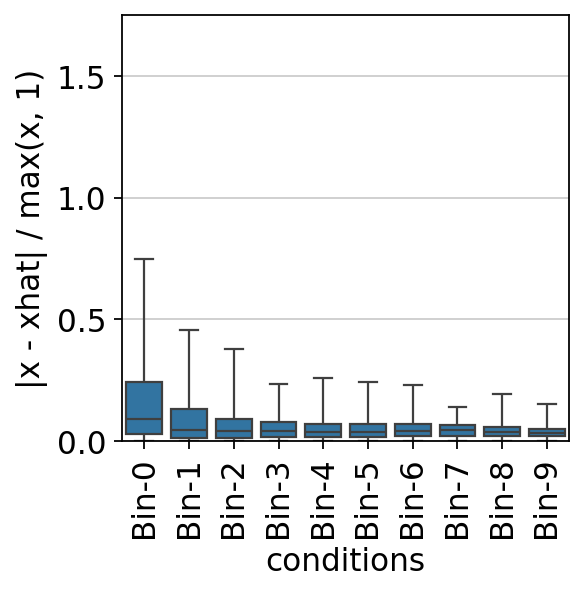

In [15]:
plot_boxplot(recon_data=scgen_reconstructed_pbmc, 
             method="scGen",
             data_name="pbmc", 
             n_genes=50, 
             restore=False, 
             score_type="median_score", 
             y_measure="AE:max(x, 1)", 
             scale="normal")

/home/sagemaker-user/.conda/envs/scgen-repro-env/lib/python3.10/site-packages/anndata/compat/__init__.py:371: FutureWarning: Moving element from .uns['neighbors']['distances'] to .obsp['distances'].

This is where adjacency matrices should go now.
  warn(
/home/sagemaker-user/.conda/envs/scgen-repro-env/lib/python3.10/site-packages/anndata/compat/__init__.py:371: FutureWarning: Moving element from .uns['neighbors']['connectivities'] to .obsp['connectivities'].

This is where adjacency matrices should go now.
  warn(


500


/tmp/ipykernel_26699/962300281.py:124: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(xlabels, rotation=90)
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: F

(3500,)


findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

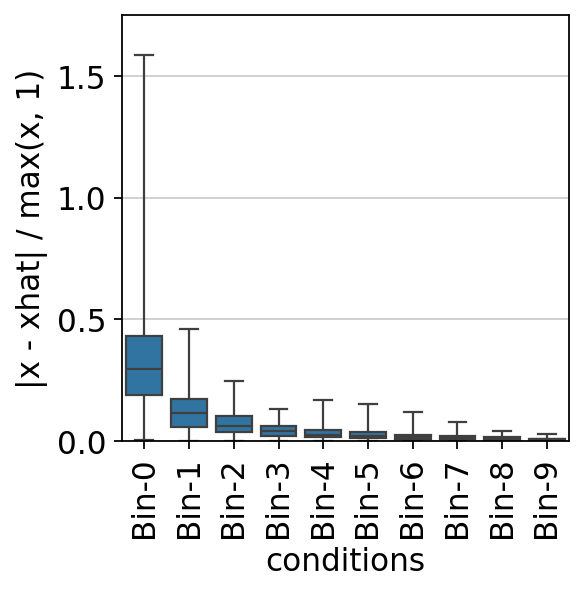

In [16]:
plot_boxplot(recon_data=pca_reconstructed_pbmc, 
             method="PCA",
             data_name="pbmc", 
             n_genes=50, 
             restore=False,  
             score_type="median_score", 
             y_measure="AE:max(x, 1)", 
             scale="normal")